In [9]:
! pip install torchviz


     ---------------------------------------- 0.0/47.1 kB ? eta -:--:--
     ---------------------------------------- 47.1/47.1 kB 2.3 MB/s eta 0:00:00



[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
! pip install pandas torch torchvision torchaudio torch-geometric pandas numpy networkx scikit-learn matplotlib


  Using cached pandas-2.2.3-cp310-cp310-win_amd64.whl (11.6 MB)
     ---------------------------------------- 0.0/204.2 MB ? eta -:--:--
     --------------------------------------- 0.2/204.2 MB 14.3 MB/s eta 0:00:15
     ---------------------------------------- 0.6/204.2 MB 8.9 MB/s eta 0:00:23
     ---------------------------------------- 1.0/204.2 MB 8.1 MB/s eta 0:00:26
     ---------------------------------------- 1.3/204.2 MB 7.5 MB/s eta 0:00:28
     ---------------------------------------- 1.7/204.2 MB 7.9 MB/s eta 0:00:26
     ---------------------------------------- 2.2/204.2 MB 7.9 MB/s eta 0:00:26
      --------------------------------------- 2.6/204.2 MB 7.9 MB/s eta 0:00:26
      --------------------------------------- 3.0/204.2 MB 7.9 MB/s eta 0:00:26
      --------------------------------------- 3.3/204.2 MB 7.9 MB/s eta 0:00:26
      --------------------------------------- 3.6/204.2 MB 8.0 MB/s eta 0:00:25
      --------------------------------------- 3.9/204.2 MB 7.8 


[notice] A new release of pip is available: 23.0.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd

df = pd.read_csv(r"E:\Manoj_honors\Merged_Data(Spatio-temporal).csv")
df.columns

Index(['Time', 'Station_ID', 'NO2', 'PM2.5', 'Ozone', 'Lat', 'Lon',
       'NO2_prev_day', 'PM2.5_prev_day', 'Ozone_prev_day', 'NO2_prev_week',
       'PM2.5_prev_week', 'Ozone_prev_week', 'Spatial_Avg_PM2.5',
       'Spatial_Avg_Ozone', 'Spatial_Avg_NO2'],
      dtype='object')

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GATv2Conv
import pandas as pd
import numpy as np
import networkx as nx
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

# Load and preprocess data
df = pd.read_csv("Merged_Data(Spatio-temporal).csv")
df = df[['Station_ID','Ozone','NO2','PM2.5','Lat','Lon',
         'NO2_prev_day', 'PM2.5_prev_day', 'Ozone_prev_day', 'NO2_prev_week',
         'PM2.5_prev_week', 'Ozone_prev_week', 'Spatial_Avg_PM2.5',
         'Spatial_Avg_Ozone', 'Spatial_Avg_NO2']]
df.dropna(inplace=True)

# Normalize features (excluding Station_ID)
features = df.columns.difference(['Station_ID'])
scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])

# Graph construction using KNN
def construct_graph(df, k=5):
    G = nx.Graph()
    stations = df[['Station_ID', 'Lon', 'Lat']].drop_duplicates().reset_index(drop=True)
    nbrs = NearestNeighbors(n_neighbors=k).fit(stations[['Lon', 'Lat']])
    distances, indices = nbrs.kneighbors(stations[['Lon', 'Lat']])

    for i, row in stations.iterrows():
        G.add_node(row['Station_ID'], pos=(row['Lon'], row['Lat']))
        for j, dist in zip(indices[i], distances[i]):
            if row['Station_ID'] != stations.loc[j, 'Station_ID']:
                G.add_edge(row['Station_ID'], stations.loc[j, 'Station_ID'], weight=np.exp(-dist))
    return G

# Convert graph to PyTorch Geometric Data
def graph_to_pyg(G, df_subset):
    edge_index = torch.tensor(list(G.edges), dtype=torch.long).t().contiguous()
    edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1) 

    x = torch.tensor(df_subset[['Station_ID','Ozone','NO2_prev_day', 'PM2.5_prev_day', 'Ozone_prev_day',
                                'NO2_prev_week', 'PM2.5_prev_week', 'Ozone_prev_week',
                                'Spatial_Avg_PM2.5','Spatial_Avg_Ozone', 'Spatial_Avg_NO2']].values, dtype=torch.float32)
    y = torch.tensor(df_subset[['NO2', 'PM2.5']].values, dtype=torch.float32)

    return Data(x=x, edge_index=edge_index, y=y)

# Hybrid GCN + Multi-GATv2 Model with BatchNorm and Dropout
class StackedGNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, heads=2, dropout=0.3):
        super(StackedGNN, self).__init__()
        self.gcn = GCNConv(input_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.gat1 = GATv2Conv(hidden_dim, hidden_dim, heads=heads, concat=True)
        self.bn2 = nn.BatchNorm1d(hidden_dim * heads)
        self.gat2 = GATv2Conv(hidden_dim * heads, hidden_dim, heads=heads, concat=True)
        self.bn3 = nn.BatchNorm1d(hidden_dim * heads)
        self.gat3 = GATv2Conv(hidden_dim * heads, hidden_dim, heads=heads, concat=True)
        self.bn4 = nn.BatchNorm1d(hidden_dim * heads)
        self.fc = nn.Linear(hidden_dim * heads, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = torch.relu(self.bn1(self.gcn(x, edge_index)))
        x = self.dropout(x)
        x = torch.relu(self.bn2(self.gat1(x, edge_index)))
        x = self.dropout(x)
        x = torch.relu(self.bn3(self.gat2(x, edge_index)))
        x = self.dropout(x)
        x = torch.relu(self.bn4(self.gat3(x, edge_index)))
        x = self.dropout(x)
        return self.fc(x)

# Evaluation metrics
def evaluate_model(model, data, target_names):
    model.eval()
    with torch.no_grad():
        predictions = model(data.x, data.edge_index).cpu().numpy()
        actual = data.y.cpu().numpy()

    for i, name in enumerate(target_names):
        y_true = actual[:, i]
        y_pred = predictions[:, i]
        print(f"\n{name} Performance:")
        print(f"  MSE   : {mean_squared_error(y_true, y_pred):.4f}")
        print(f"  MAE   : {mean_absolute_error(y_true, y_pred):.4f}")
        print(f"  R2    : {r2_score(y_true, y_pred):.4f}")
        print(f"  MAPE  : {mean_absolute_percentage_error(y_true, y_pred):.4f}")
        print(f"  NRMSE : {np.sqrt(mean_squared_error(y_true, y_pred)) / (y_true.max() - y_true.min()):.4f}")

# Prepare data
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
G = construct_graph(df, k=5)
train_data = graph_to_pyg(G, train_df)
test_data = graph_to_pyg(G, test_df)

# Move to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_data = train_data.to(device)
test_data = test_data.to(device)

# Model setup
input_dim = train_data.x.shape[1]
model = StackedGNN(input_dim=input_dim, hidden_dim=64, output_dim=2, heads=2, dropout=0.3).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=200, gamma=0.7)

# Combined loss
def combined_loss(output, target):
    return nn.MSELoss()(output, target) + 0.3 * nn.L1Loss()(output, target)

# Training loop with early stopping
best_loss = float('inf')
patience = 100
counter = 0
epochs = 2000

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(train_data.x, train_data.edge_index)
    loss = combined_loss(output, train_data.y)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()

    if loss.item() < best_loss:
        best_loss = loss.item()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    if epoch % 50 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

# Final Evaluation
evaluate_model(model, test_data, target_names=["NO2", "PM2.5"])


Epoch 0 | Loss: 1.4911
Epoch 50 | Loss: 0.5700
Epoch 100 | Loss: 0.4905
Epoch 150 | Loss: 0.4595
Epoch 200 | Loss: 0.4448
Epoch 250 | Loss: 0.4405
Epoch 300 | Loss: 0.4345
Epoch 350 | Loss: 0.4300
Epoch 400 | Loss: 0.4271
Epoch 450 | Loss: 0.4250
Epoch 500 | Loss: 0.4224
Epoch 550 | Loss: 0.4206
Epoch 600 | Loss: 0.4186
Epoch 650 | Loss: 0.4183
Epoch 700 | Loss: 0.4165
Epoch 750 | Loss: 0.4149
Epoch 800 | Loss: 0.4143
Epoch 850 | Loss: 0.4137
Epoch 900 | Loss: 0.4124
Epoch 950 | Loss: 0.4118
Epoch 1000 | Loss: 0.4101
Epoch 1050 | Loss: 0.4109
Epoch 1100 | Loss: 0.4100
Epoch 1150 | Loss: 0.4093
Epoch 1200 | Loss: 0.4087
Epoch 1250 | Loss: 0.4081
Epoch 1300 | Loss: 0.4077
Epoch 1350 | Loss: 0.4073
Epoch 1400 | Loss: 0.4068
Epoch 1450 | Loss: 0.4071
Epoch 1500 | Loss: 0.4061
Epoch 1550 | Loss: 0.4061
Epoch 1600 | Loss: 0.4057
Epoch 1650 | Loss: 0.4054
Epoch 1700 | Loss: 0.4054
Early stopping at epoch 1749

NO2 Performance:
  MSE   : 0.3514
  MAE   : 0.3315
  R2    : 0.6460
  MAPE  : 1.959

In [12]:
# Print basic graph info manually
print("Graph Info:")
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

# Print all edges with weights
print("\nEdges with weights:")
for u, v, data in G.edges(data=True):
    print(f"{u} -- {v} [weight = {data['weight']:.4f}]")

# Optionally, print node coordinates
print("\nNode positions:")
for node, attr in G.nodes(data=True):
    lon, lat = attr['pos']
    print(f"Station {node}: (Lon = {lon:.4f}, Lat = {lat:.4f})")


Graph Info:
Number of nodes: 39
Number of edges: 102

Edges with weights:
0.0 -- 23 [weight = 0.5431]
0.0 -- 8 [weight = 0.4010]
0.0 -- 14 [weight = 0.3702]
0.0 -- 30 [weight = 0.3497]
23 -- 4.0 [weight = 0.4425]
23 -- 8.0 [weight = 0.4214]
23 -- 30 [weight = 0.3381]
8 -- 4.0 [weight = 0.4602]
8 -- 30 [weight = 0.7942]
8 -- 14 [weight = 0.4812]
8 -- 20.0 [weight = 0.4179]
14 -- 2.0 [weight = 0.6314]
14 -- 5 [weight = 0.6900]
14 -- 34 [weight = 0.6746]
14 -- 30 [weight = 0.5487]
30 -- 4.0 [weight = 0.3815]
30 -- 20.0 [weight = 0.4667]
30 -- 34 [weight = 0.5155]
30 -- 31 [weight = 0.4961]
2.0 -- 34 [weight = 0.8197]
2.0 -- 5 [weight = 0.6540]
2.0 -- 26 [weight = 0.5918]
2.0 -- 37.0 [weight = 0.4394]
34 -- 31.0 [weight = 0.6017]
34 -- 26 [weight = 0.6029]
34 -- 5.0 [weight = 0.5940]
5 -- 37.0 [weight = 0.5493]
26 -- 32.0 [weight = 0.8379]
26 -- 39 [weight = 0.8607]
26 -- 33 [weight = 0.7753]
26 -- 31 [weight = 0.6837]
26 -- 19.0 [weight = 0.5709]
4.0 -- 20 [weight = 0.3266]
20 -- 31 [weig

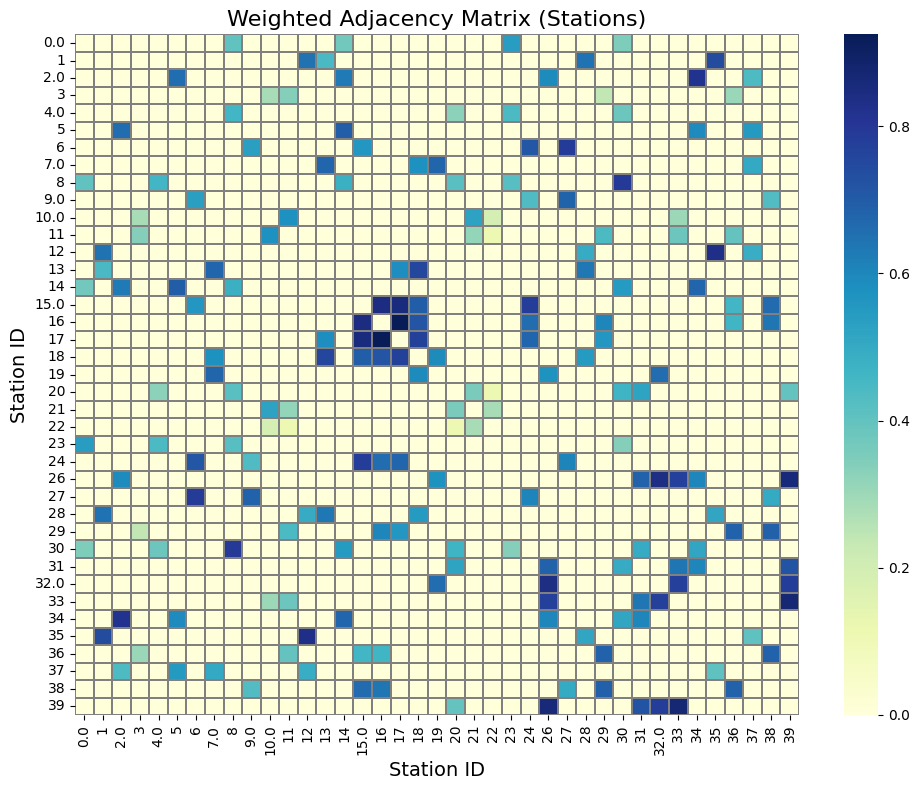

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_weighted_adjacency_matrix_with_labels(G):
    # Get sorted list of nodes
    nodes = sorted(G.nodes())
    node_to_idx = {node: i for i, node in enumerate(nodes)}

    # Initialize adjacency matrix
    adj_matrix = np.zeros((len(nodes), len(nodes)))

    for u, v, data in G.edges(data=True):
        i, j = node_to_idx[u], node_to_idx[v]
        weight = data['weight']
        adj_matrix[i, j] = weight
        adj_matrix[j, i] = weight  # Since undirected

    # Plot heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(adj_matrix, 
                xticklabels=nodes, 
                yticklabels=nodes, 
                cmap='YlGnBu', 
                linewidths=0.3,
                linecolor='gray')
    plt.title("Weighted Adjacency Matrix (Stations)", fontsize=16)
    plt.xlabel("Station ID", fontsize=14)
    plt.ylabel("Station ID", fontsize=14)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Usage
plot_weighted_adjacency_matrix_with_labels(G)


C:\Users\USER1\AppData\Local\Temp\ipykernel_20156\881869528.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


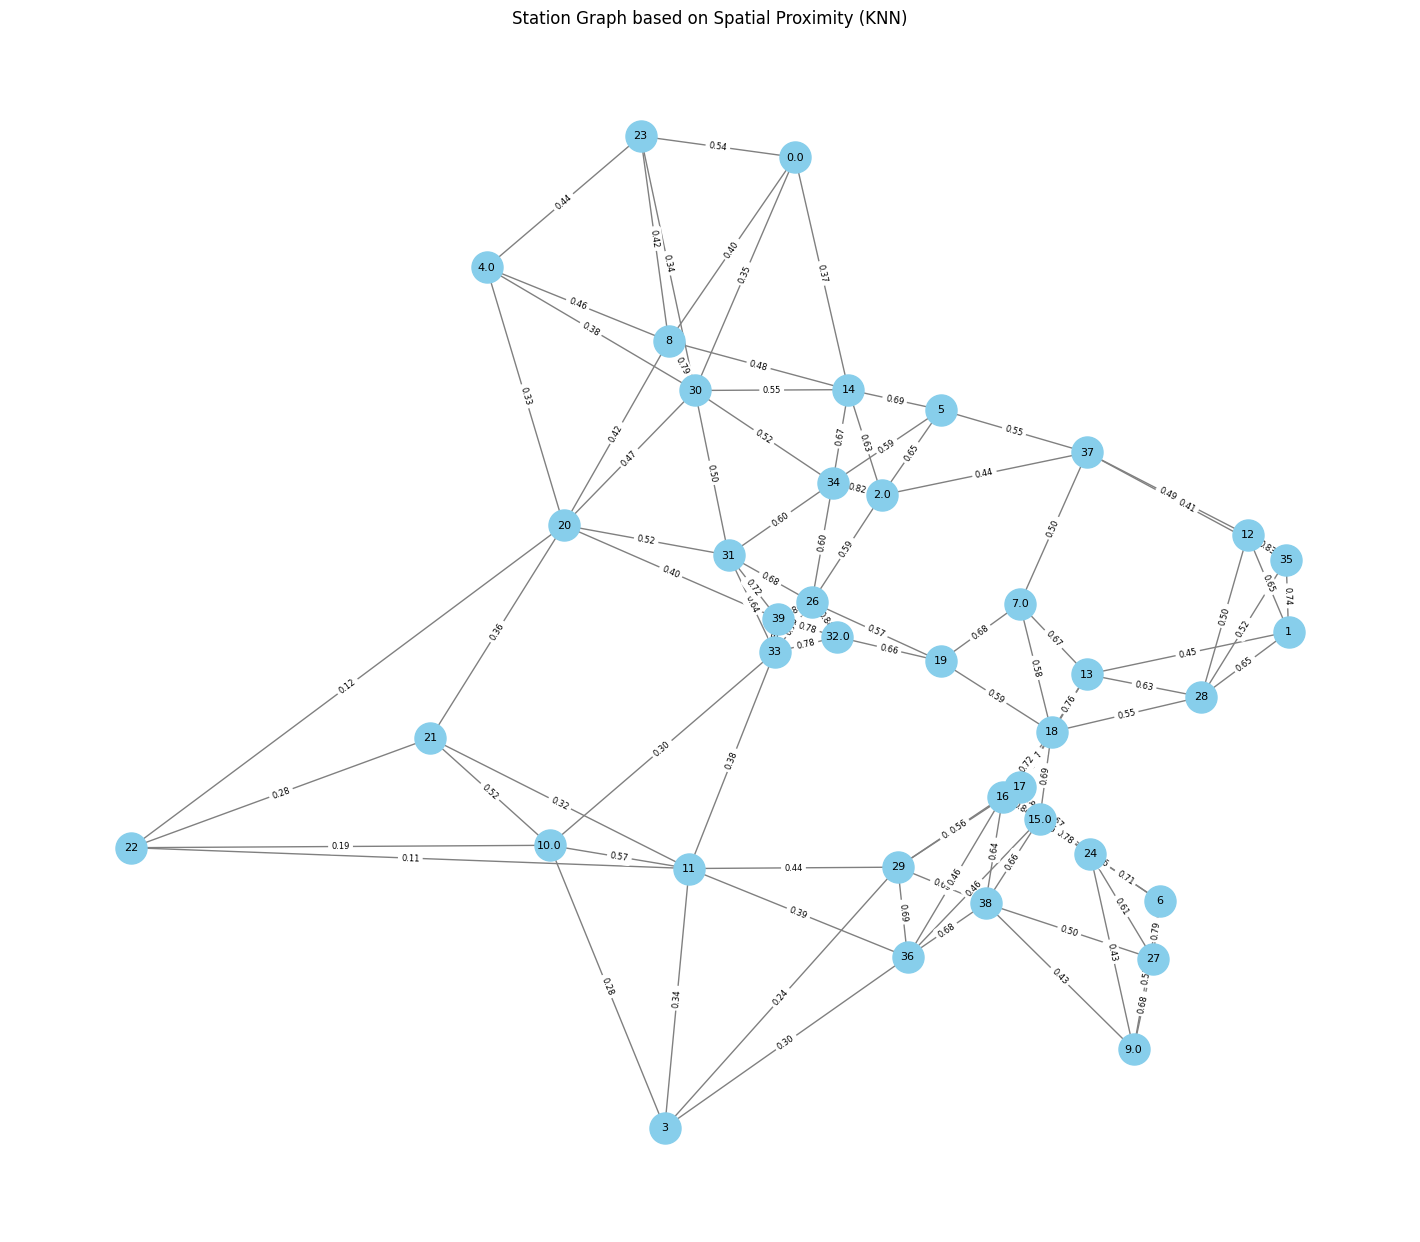

In [13]:
import matplotlib.pyplot as plt

# Get positions from node attributes (lon, lat)
pos = {node: attr['pos'] for node, attr in G.nodes(data=True)}

# Draw the graph
plt.figure(figsize=(14, 12))
nx.draw(G, pos, with_labels=True, node_color='skyblue', edge_color='gray', node_size=500, font_size=8)

# Draw edge weights
edge_labels = nx.get_edge_attributes(G, 'weight')
formatted_labels = {k: f"{v:.2f}" for k, v in edge_labels.items()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=formatted_labels, font_size=6)

plt.title("Station Graph based on Spatial Proximity (KNN)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.tight_layout()
plt.show()


In [24]:
! pip install tensorboard


     ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
     ---------------------------------------- 0.0/5.5 MB 640.0 kB/s eta 0:00:09
     ---------------------------------------- 0.0/5.5 MB 640.0 kB/s eta 0:00:09
     ---------------------------------------- 0.0/5.5 MB 640.0 kB/s eta 0:00:09
     ---------------------------------------- 0.1/5.5 MB 297.7 kB/s eta 0:00:19
      --------------------------------------- 0.1/5.5 MB 435.7 kB/s eta 0:00:13
      --------------------------------------- 0.1/5.5 MB 435.7 kB/s eta 0:00:13
      --------------------------------------- 0.1/5.5 MB 435.7 kB/s eta 0:00:13
      --------------------------------------- 0.1/5.5 MB 343.4 kB/s eta 0:00:16
     - -------------------------------------- 0.1/5.5 MB 387.0 kB/s eta 0:00:14
     - -------------------------------------- 0.2/5.5 MB 478.0 kB/s eta 0:00:12
     - -------------------------------------- 0.2/5.5 MB 502.2 kB/s eta 0:00:11
     -- ------------------------------------- 0.3


[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
! pip install torchsummary


[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
